# Feature Selection : Filter Method

Feature selection is the process of choosing the most relevant features (columns) for your machine learning model. It helps to:

- Improve model performance

- Reduce overfitting

- Speed up training time

- Make models more interpretable

**Feature Selection Methods:**

| Type         | Examples                                    | Description                                    |
| ------------ | ------------------------------------------- | ---------------------------------------------- |
| **Filter**   | Correlation, Chi-square, Mutual Information | Fast, statistical methods independent of model |
| **Wrapper**  | RFE, Forward/Backward Selection             | Use model performance to evaluate subsets      |
| **Embedded** | Lasso, Tree-based Feature Importance        | Selection happens during model training        |


- **Filter:**
    - **Features Correlation** (for numerical features) : Measures the correlation between each feature and the target variable. Features with high correlation are selected.
    - **Chi-Square Test** (for categorical features) : Tests independence between feature and target variable.
    - **Mutual Information** : (for categorical features) : Measures the dependency between features and target.
    - **Cramér’s V** (Categorical-Categorical) : Strength of association
    - **Theil’s U** (Categorical-Categorical) : Predictive power

**Q.** With feature selction aren't we selecting the models as well , cause we are validating their performance on fetaures simultaneously ?

Short Answer:

> Feature selection optimizes the input space for a given model.
>
> Model selection optimizes the hypothesis space itself.

**See Run Results :** [https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow](https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow/#/)

In [ ]:
# TRIGGER_FLAG: run 01
# KAGGLE_CONFIG: enable_gpu = false
# KAGGLE_CONFIG: enable_tpu = false
# KAGGLE_CONFIG: keywords = ["healthcare", "classification", "feature-selection"]
# KAGGLE_CONFIG: dataset_sources = ["rahulshelke98/healthcare-dataset-stroke-data-csv"]
# KAGGLE_CONFIG: kernel_sources = ["rahulshelke98/01-02-data-quality-correction", "rahulshelke98/02-03-handling-missing-values", "rahulshelke98/02-04-handling-outliers", "rahulshelke98/03-feature-engineering"]

## Required Installtion

In [ ]:
import os
import sys

# Check if running in Kaggle Cloud Environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    print("--- Kaggle Environment Detected: Installing Cloud Dependencies ---")
    # 1. Install general cloud dependencies
    os.system(f"{sys.executable} -m pip install -q mlflow dagshub")
    
    # 2. Clone the specific branch of the repository
    print("Install custome package...")
    # os.system("git clone -b feat/notebooks https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git")
    os.system(f"{sys.executable} -m pip install -q git+https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git@feat/notebooks")
    
else:
    print("--- Local/Non-Kaggle Environment Detected: Skipping Installation ---")
    # Local packages should ideally be pre-managed via your local uv environment

## Smart Environment Detection & Secrets Setup

In [ ]:
# PRODUCTION MLOPS NOTEBOOK
# Note: This notebook runs automatically in an headless CI/CD pipeline.
# If you fork this notebook to run it yourself, make sure to set up your 
# own DagsHub repository variables or track experiments locally.

import os
import mlflow
from dotenv import load_dotenv

# 1. Safely retrieve credentials from Kaggle's internal secure vault
try:
    # 1. Detect if running inside Kaggle's container
    IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

    if IS_KAGGLE:
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    else:
        load_dotenv()
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME", "Rahul-404")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    
    # Replace this with your actual DagsHub repo name
    REPO_NAME = "heart-stroke-prediction"
    
    # 2. Inject environment variables that the MLflow client natively looks for
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    
    # 3. Set the remote tracking URI to point to DagsHub
    tracking_uri = f"https://dagshub.com/{DAGSHUB_USERNAME}/{REPO_NAME}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
    
    print("Successfully connected to DagsHub MLflow tracking server!")
except Exception as e:
    # print(f"Local or non-Kaggle execution environment detected: {e}")
    print(f"Error establishing MLflow/DagsHub context: {e}")

## Unified Path Setup Strategy

In [ ]:
import os
from pathlib import Path

# 1. Reuse your environment checker flag
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    # --- KAGGLE CLOUD PATH CONTEXT ---
    # Fetch environment variables injected by your Kaggle configuration
    KAGGLE_USER = os.environ.get("KAGGLE_USER")
    DATASET_SLUG = os.environ.get("KAGGLE_DATASET_NAME")
    NOTEBOOK_1 = "01-02-data-quality-correction"
    NOTEBOOK_2 = "02-03-handling-missing-values"
    NOTEBOOK_3 = "02-04-handling-outliers"
    NOTEBOOK_4 = "03-feature-engineering"

    # Kaggle mounts datasets directly under /kaggle/input/dataset-slug
    INPUT_DATA_DIR = Path(f"/kaggle/input/datasets/{KAGGLE_USER}/{DATASET_SLUG}")
    INPUT_ARTIFACT_1_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_1}")
    INPUT_ARTIFACT_2_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_2}")
    INPUT_ARTIFACT_3_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_3}")
    INPUT_ARTIFACT_4_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_4}")

    if not INPUT_DATA_DIR.exists():
        raise FileNotFoundError(f"Kaggle Input Directory does not exist: {INPUT_DATA_DIR}")

    if not INPUT_ARTIFACT_1_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_1_DIR}")
    
    if not INPUT_ARTIFACT_2_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_2_DIR}")
    
    if not INPUT_ARTIFACT_3_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_3_DIR}")
    
    if not INPUT_ARTIFACT_4_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_4_DIR}")
    
    INPUT_DIR = {
        'data': INPUT_DATA_DIR,
        'data_correct': INPUT_ARTIFACT_1_DIR,
        'handle_missing': INPUT_ARTIFACT_2_DIR,
        'handle_missing_val': INPUT_ARTIFACT_2_DIR,
        'handle_outlier': INPUT_ARTIFACT_3_DIR,
        'engineering_pipeline': INPUT_ARTIFACT_4_DIR
    }
    
    # Kaggle strictly allows file writing ONLY inside /kaggle/working
    OUTPUT_DIR = Path("/kaggle/working")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

else:
    # --- LOCAL ENVIRONMENT PATH CONTEXT ---
    current_directory = Path.cwd()

    # Keeps your local repo clean by saving local run artifacts into an artifacts folder
    OUTPUT_DIR = current_directory / "notebooks" / "artifact"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Points to your local repository structure (e.g., repository_root/notebooks/data/)
    INPUT_DATA_DIR = current_directory / "notebooks" / "data"
    INPUT_ARTIFACT_DIR = current_directory / "notebooks" / "artifact"

    if not INPUT_DATA_DIR.exists():
        raise FileNotFoundError(f"Local Input Directory does not exist: {INPUT_DATA_DIR}")

    if not INPUT_ARTIFACT_DIR.exists():
        raise FileNotFoundError(f"Local Artifact Directory does not exist: {INPUT_ARTIFACT_DIR}")

    INPUT_DIR = {
        'data': INPUT_DATA_DIR,
        'data_correct': INPUT_ARTIFACT_DIR,
        'handle_missing': INPUT_ARTIFACT_DIR,
        'handle_missing_val': INPUT_ARTIFACT_DIR,
        'handle_outlier': INPUT_ARTIFACT_DIR,
        'engineering_pipeline': INPUT_ARTIFACT_DIR
    }

print("--- PATH SUMMARY ---")
print(f"Execution Target:    {'Kaggle Cloud' if IS_KAGGLE else 'Local Machine'}")
print(f"Reading Input From:  {INPUT_DIR}")
print(f"Writing Outputs To: {OUTPUT_DIR}")

In [ ]:
DATA_FILE_NAME = {
    'raw': Path(INPUT_DIR['data'], 'healthcare-dataset-stroke-data.csv'),
    'clean': Path(INPUT_DIR['data_correct'], 'heart_stroke_data.csv'),
}

ARTIFACT_FILE_NAME = {
    'data_correct': Path(INPUT_DIR['data_correct'], 'data_correction_pipeline.pkl'),
    'handle_missing': Path(INPUT_DIR['handle_missing'], 'missing_imputer_pipeline.pkl'),
    'handle_missing_val': Path(INPUT_DIR['handle_missing_val'], 'missing_imputer_validation_pipeline.pkl'),
    'handle_outlier': Path(INPUT_DIR['handle_outlier'], 'outlier_handler_pipeline.pkl'),
    'engineering_pipeline': Path(INPUT_DIR['engineering_pipeline'], 'feature_engineering_pipeline.pkl'),
}

### Set Experiment Name

In [ ]:
experiment_name = "04_00_Feature_Selection_Filter_Method"
experiment_tags = {
    "experiment_type": "Classification",
    "project": "heart_stroke_risk_stratification",
    "team": "Data_Science_Core"
}

try:
    experiment_id = mlflow.create_experiment(name=experiment_name, tags=experiment_tags)
except Exception:
    # If it already exists, fetch its ID
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

# 3. Set it as the active experiment
mlflow.set_experiment(experiment_id=experiment_id)

### Set Run Name

In [ ]:
# Starts a global active run
mlflow.start_run(run_name="Feature_Selection_Filtering_Session")

## Imports

In [ ]:
from heart_stroke_prediction.analyze.feature_selection.filter_methods import Filter
import pandas as pd
import cloudpickle
import os

from sklearn import set_config
# Set global configuration to output Pandas DataFrames
set_config(transform_output="pandas")

import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATA_FILE_NAME = {
    'raw': Path(INPUT_DIR['data'], 'healthcare-dataset-stroke-data.csv'),
    'clean': Path(INPUT_DIR['data_correct'], 'heart_stroke_data.csv'),
}

ARTIFACT_FILE_NAME = {
    'data_correct': Path(INPUT_DIR['data_correct'], 'data_correction_pipeline.pkl'),
    'handle_missing': Path(INPUT_DIR['handle_missing'], 'missing_imputer_pipeline.pkl'),
    'handle_missing_val': Path(INPUT_DIR['handle_missing_val'], 'missing_imputer_validation_pipeline.pkl'),
    'handle_outlier': Path(INPUT_DIR['handle_outlier'], 'outlier_handler_pipeline.pkl'),
    'engineering_pipeline': Path(INPUT_DIR['engineering_pipeline'], 'feature_engineering_pipeline.pkl'),
}

## Read Data

In [ ]:
with open(ARTIFACT_FILE_NAME["data_correct"], "rb") as f:
    static_pipeline = cloudpickle.load(f)

In [9]:
static_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


In [10]:
os.getcwd()

'/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks'

In [ ]:
df = pd.read_csv(DATA_FILE_NAME['raw'])
df = static_pipeline.fit_transform(df)

In [12]:
df.shape

(5109, 12)

In [13]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [14]:
df.isna().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

In [15]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [16]:
TARGET_COL = ['stroke']
ID_COL = ['id']
NUM_FEATURES = ['age', 'bmi', 'avg_glucose_level']
CAT_FEATURES = [ 'gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status', 'hypertension', 'heart_disease']

In [ ]:
with open(ARTIFACT_FILE_NAME["engineering_pipeline"], "rb") as f:
    dynamic_pipeline = cloudpickle.load(f)

In [18]:
dynamic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [19]:
# feature_engineering_pipeline = joblib.load(os.path.join(ARTIFACT_PATH, "feature_engineering_pipeline_v1.pkl"))
df_composed = dynamic_pipeline.fit_transform(df)
df_composed[TARGET_COL] = df[TARGET_COL]

In [20]:
df_composed.head()

,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,...,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,avg_glucose_level_sqrt,hypertension,heart_disease,age,missingindicator_bmi,stroke
0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.546269,8370.054,8.185353,6.049793,15.122500,0,1,67.0,0.0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.460656,5682.101,7.810250,5.300943,14.220056,0,0,61.0,1.0,1
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.406250,3442.400,8.944272,5.700877,10.291744,0,1,80.0,0.0,1
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.702041,5890.312,7.000000,5.865151,13.085488,0,0,49.0,0.0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.303797,4178.880,8.888194,4.898979,13.195454,1,0,79.0,0.0,1


In [21]:
df_composed.shape

(5109, 29)

In [22]:
df_composed.columns

Index(['gender_male', 'ever_married_yes', 'residence_type_urban',
       'work_type_children', 'work_type_govt_job', 'work_type_never_worked',
       'work_type_private', 'work_type_self_employed',
       'smoking_status_formerly_smoked', 'smoking_status_missing',
       'smoking_status_never_smoked', 'smoking_status_smokes',
       'missingindicator_smoking_status_True', 'bmi', 'avg_glucose_level',
       'bmi_health_category', 'glucose_health_category',
       'age_avg_glucose_interaction', 'age_bmi_interaction', 'bmi_age_ratio',
       'avg_glucose_bmi_ratio', 'age_sqrt', 'bmi_sqrt',
       'avg_glucose_level_sqrt', 'hypertension', 'heart_disease', 'age',
       'missingindicator_bmi', 'stroke'],
      dtype='object')

In [23]:
df_composed.shape

(5109, 29)

In [24]:
NUM_FEATURES = ['bmi', 'avg_glucose_level','age_avg_glucose_interaction', 'age_bmi_interaction', 'bmi_age_ratio',
                'avg_glucose_bmi_ratio', 'age_sqrt', 'bmi_sqrt', 'avg_glucose_level_sqrt','age', 'missingindicator_bmi']
CAT_FEATURES = ['gender_male', 'ever_married_yes', 'residence_type_urban',
                'work_type_children', 'work_type_govt_job', 'work_type_never_worked',
                'work_type_private', 'work_type_self_employed',
                'smoking_status_formerly_smoked', 'smoking_status_missing',
                'smoking_status_never_smoked', 'smoking_status_smokes',
                'missingindicator_smoking_status_True', 'bmi_health_category', 
                'glucose_health_category','hypertension', 'heart_disease',]

# Feature Selection Methods

In [25]:
features = NUM_FEATURES + CAT_FEATURES + TARGET_COL

In [26]:
# features

In [27]:
# Shapiro-Wilk test was originally designed and mathematically validated for small to medium sample sizes, typically up to 5,000 observations
from sklearn.model_selection import train_test_split
train, test = train_test_split(df_composed, test_size=0.30, stratify=df_composed['stroke'])

In [28]:
train['stroke'].value_counts()

stroke
0    3402
1     174
Name: count, dtype: int64

In [29]:
test['stroke'].value_counts()

stroke
0    1458
1      75
Name: count, dtype: int64

In [30]:
train.shape, test.shape

((3576, 29), (1533, 29))

In [31]:
# (174+75),  (1458 + 3403)

## 1. Filter Methods

In [32]:
fm = Filter(train)

### 1.1 Correlation

In [33]:
corr_df = fm._check_correlation(NUM_FEATURES+CAT_FEATURES+TARGET_COL)

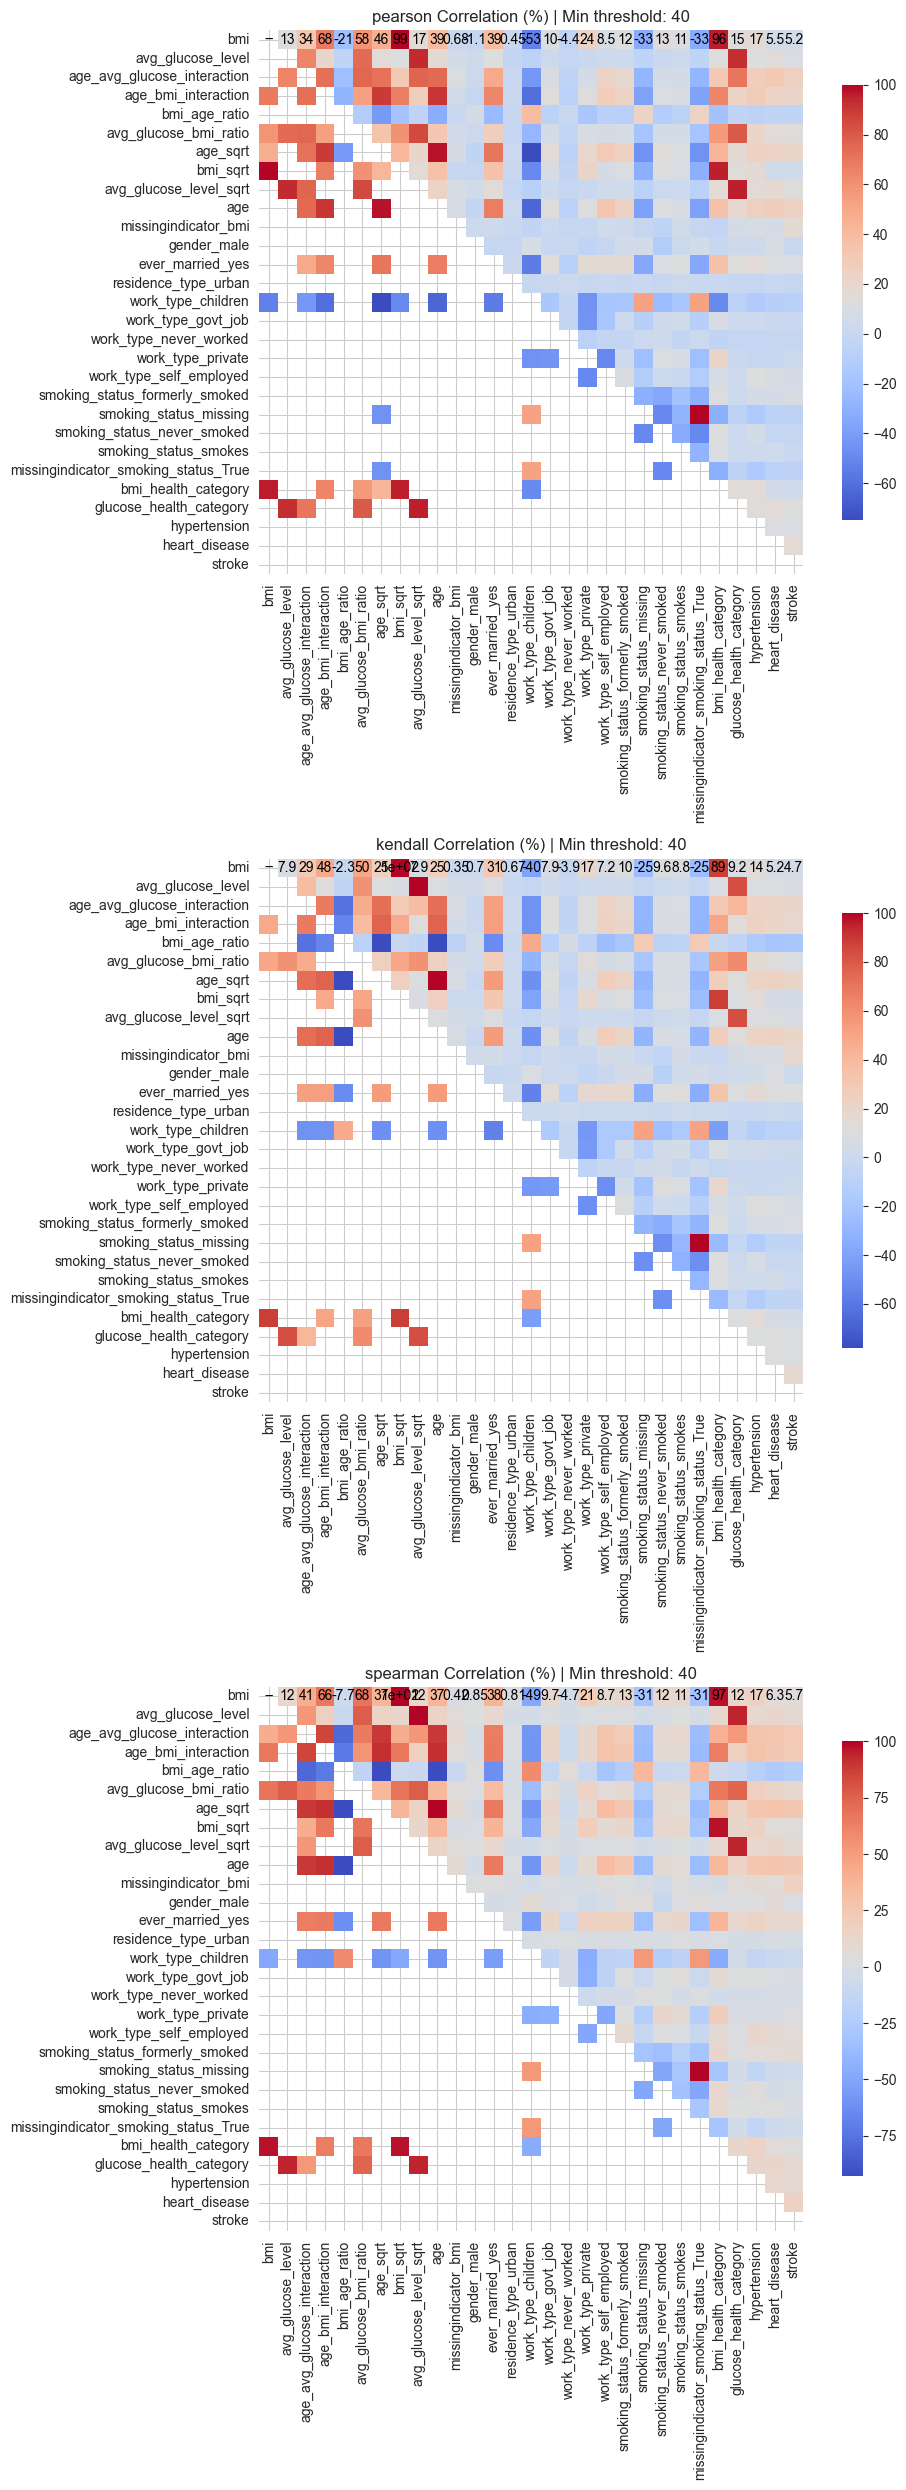

In [34]:
fm.plot_correlation(corr_df, width=25, height=10)

### 1.2 Statistical Tests

In [35]:
statistically_selected = fm.statistical_filtering(NUM_FEATURES, CAT_FEATURES, TARGET_COL[0])
statistically_selected

,Feature,Type,Distrbution,Test Performed,P Value,Is Selected?
0,bmi,numerical,Normal,t-test:2 sample,1.689269e-03,Yes
1,avg_glucose_level,numerical,Normal,t-test:2 sample,3.227758e-10,Yes
2,age_avg_glucose_interaction,numerical,Normal,t-test:2 sample,1.516297e-55,Yes
3,age_bmi_interaction,numerical,Normal,t-test:2 sample,1.066496e-38,Yes
4,bmi_age_ratio,numerical,Normal,t-test:2 sample,5.889107e-03,Yes
5,avg_glucose_bmi_ratio,numerical,Normal,t-test:2 sample,5.745050e-16,Yes
6,age_sqrt,numerical,Normal,t-test:2 sample,1.131073e-39,Yes
7,bmi_sqrt,numerical,Normal,t-test:2 sample,7.493806e-03,Yes
8,avg_glucose_level_sqrt,numerical,Normal,t-test:2 sample,7.729399e-17,Yes
9,age,numerical,Normal,t-test:2 sample,3.847231e-51,Yes


In [36]:
state_features = statistically_selected[statistically_selected["Is Selected?"] == 'Yes']['Feature'].to_list()

In [37]:
state_features

['bmi',
 'avg_glucose_level',
 'age_avg_glucose_interaction',
 'age_bmi_interaction',
 'bmi_age_ratio',
 'avg_glucose_bmi_ratio',
 'age_sqrt',
 'bmi_sqrt',
 'avg_glucose_level_sqrt',
 'age',
 'missingindicator_bmi',
 'ever_married_yes',
 'work_type_children',
 'work_type_self_employed',
 'smoking_status_formerly_smoked',
 'smoking_status_missing',
 'missingindicator_smoking_status_True',
 'bmi_health_category',
 'glucose_health_category',
 'hypertension',
 'heart_disease']

### 1.3 Mutual Information

- f-test: captures only linear dependency
- mi: captures any kind of dependency between variables

In [38]:
fm.mi_dataframe(NUM_FEATURES, CAT_FEATURES, TARGET_COL[0])

,feature,f_test_score,mi_score,Is_selected?
0,bmi,0.038691,0.160276,yes
1,avg_glucose_level,0.155774,0.052850,yes
2,age_avg_glucose_interaction,1.000000,0.815857,yes
3,age_bmi_interaction,0.679298,0.917684,yes
4,bmi_age_ratio,0.029751,0.783808,yes
5,avg_glucose_bmi_ratio,0.259134,0.208125,yes
6,age_sqrt,0.697642,1.000000,yes
7,bmi_sqrt,0.028049,0.138428,yes
8,avg_glucose_level_sqrt,0.274928,0.058270,yes
9,age,0.915436,0.936871,yes


In [39]:
# fm.visualize_mi_with_pywidget(NUM_FEATURES, CAT_FEATURES, TARGET_COL[0], width=7, height=5)

### 1.4 Variance Threshold

here will use features which has high variability, so for that will setup a threshold.

In [40]:
fm.variance_threshold(
    feature_list=NUM_FEATURES+CAT_FEATURES, 
    data=df_composed,
    threshold=0.2
)

,feature,variance,std_dev,Is_selected?
0,age_avg_glucose_interaction,1.508193e+07,3883.545868,yes
1,avg_glucose_bmi_ratio,3.221917e+06,1794.969904,yes
2,age_bmi_interaction,5.811142e+05,762.308466,yes
3,age,5.112737e+02,22.611362,yes
4,bmi_age_ratio,3.661950e+01,6.051405,yes
5,age_sqrt,4.106509e+00,2.026452,yes
6,avg_glucose_level_sqrt,3.944734e+00,1.986135,yes
7,bmi_health_category,2.062469e+00,1.436130,yes
8,glucose_health_category,1.269448e+00,1.126698,yes
9,bmi,1.000000e+00,1.000000,yes


In [41]:
state_features

['bmi',
 'avg_glucose_level',
 'age_avg_glucose_interaction',
 'age_bmi_interaction',
 'bmi_age_ratio',
 'avg_glucose_bmi_ratio',
 'age_sqrt',
 'bmi_sqrt',
 'avg_glucose_level_sqrt',
 'age',
 'missingindicator_bmi',
 'ever_married_yes',
 'work_type_children',
 'work_type_self_employed',
 'smoking_status_formerly_smoked',
 'smoking_status_missing',
 'missingindicator_smoking_status_True',
 'bmi_health_category',
 'glucose_health_category',
 'hypertension',
 'heart_disease']

In [ ]:
# Make sure to close the run so MLflow knows the notebook is done
mlflow.end_run()

**Next Actions:**
- Wrapper method